# Cierra los ojos e imagina una tortuga. ¿Tu cerebro la está «viendo»?

**Paper:** Wadia, V. S. *et al.* (2026). *A shared code for perceiving and imagining objects in human ventral temporal cortex*. **Science**.

**DOI:** [10.1126/science.adt8343](https://doi.org/10.1126/science.adt8343)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-15-codigo-neural-percepcion-imaginacion/notebook.ipynb)

**Video:** [Pendiente]

## El experimento

16 pacientes con epilepsia ya tenían electrodos implantados en el cerebro para localizar el foco de sus crisis. Mientras esperaban cirugía, participaron en dos tareas:

1. **Screening visual:** les mostraron 500 objetos distintos (tortugas, pianos, baterías, camarones...) y grabaron la respuesta de cada neurona.
2. **Imaginería:** les pidieron que *imaginaran* algunos de esos mismos objetos —sin verlos— y grabaron las mismas neuronas.

La zona: la **corteza temporal ventral** (VTC), donde el cerebro humano reconoce objetos. El equipo — Caltech y Cedars-Sinai — grabó 367 neuronas individuales en esta región. La pregunta: ¿el cerebro reutiliza el mismo código para ver e imaginar?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_NEURONAS_VIS = 367          # Neuronas axis-tuned en VTC
N_NEURONAS_IMAG = 43          # Neuronas que reactivaron durante imaginería
N_PACIENTES = 16              # Pacientes epilépticos
N_ESTIMULOS = 500             # Objetos distintos mostrados
FUENTE = 'Fuente: Wadia et al. (2026), Science | Datos: OSF (doi:10.17605/OSF.IO/G9XH6)'
COLOR_VIS = '#2563EB'         # Azul CaM — respuestas visuales
COLOR_IMAG = '#DC2626'        # Rojo — respuestas de imaginería
COLOR_ENC = '#059669'         # Emerald — encoding
COLOR_HEMI_L = '#7C3AED'     # Violeta — hemisferio izquierdo
COLOR_HEMI_R = '#D97706'     # Amber — hemisferio derecho
COLOR_FONDO = '#BBBBBB'      # Gris — contexto

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_paths = ['../../cam.mplstyle', '/tmp/cam.mplstyle']
style_loaded = False
for sp in style_paths:
    if os.path.exists(sp):
        plt.style.use(sp)
        style_loaded = True
        break
if not style_loaded:
    url = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle'
    urllib.request.urlretrieve(url, '/tmp/cam.mplstyle')
    plt.style.use('/tmp/cam.mplstyle')

# Cargar datos
neurons = pd.read_csv('datos/neuronas_visuales.csv')
profiles = pd.read_csv('datos/perfil_ejemplo.csv')
imagery = pd.read_csv('datos/vision_vs_imagineria.csv')
corrs = pd.read_csv('datos/correlaciones_neuronas.csv')

print(f"Neuronas visuales: {len(neurons)} de {neurons['patient_id'].nunique()} pacientes")
print(f"  LVTC (izquierdo): {(neurons['brain_area'] == 'LVTC').sum()}")
print(f"  RVTC (derecho): {(neurons['brain_area'] == 'RVTC').sum()}")
print(f"Neuronas de imaginería: {len(corrs)}")
print(f"Pares visual-imaginería: {len(imagery)}")
print(f"Latencia mediana: {neurons['latency_ms'].median():.1f} ms")

Neuronas visuales: 367 de 16 pacientes
  LVTC (izquierdo): 193
  RVTC (derecho): 174
Neuronas de imaginería: 43
Pares visual-imaginería: 338
Latencia mediana: 159.4 ms


## ¿Cómo «ve» una neurona?

No como un interruptor. Aquí está.

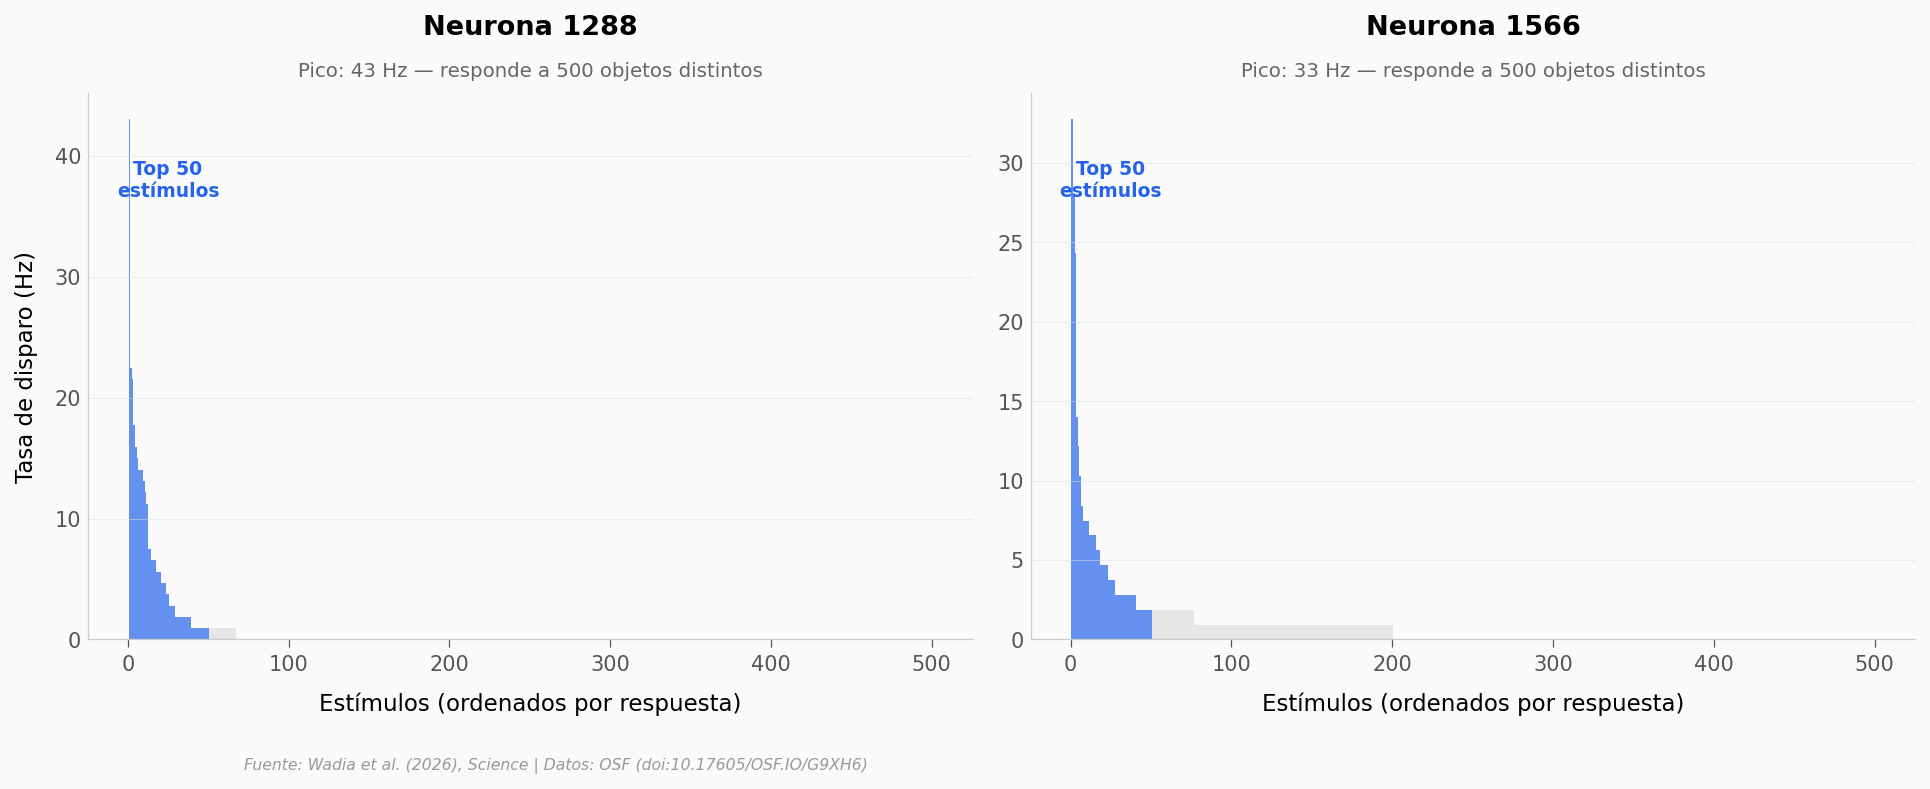

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for idx, (col, ax) in enumerate(zip(['neuron_1_hz', 'neuron_2_hz'], axes)):
    values = profiles[col].values
    ranks = profiles['stimulus_rank'].values

    # Fondo gris para todo, azul para los que más activan
    top_n = 50
    ax.bar(ranks[top_n:], values[top_n:], width=1, color=COLOR_FONDO, alpha=0.3)
    ax.bar(ranks[:top_n], values[:top_n], width=1, color=COLOR_VIS, alpha=0.7)

    ax.set_xlabel('Estímulos (ordenados por respuesta)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Tasa de disparo (Hz)', fontsize=11)

    neuron_name = profiles[f'neuron_{idx+1}_name'].iloc[0]
    max_hz = values[0]
    ax.set_title(f'Neurona {neuron_name}',
                 fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, f'Pico: {max_hz:.0f} Hz — responde a {N_ESTIMULOS} objetos distintos',
            transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')

    # Inline label
    ax.text(top_n // 2, max_hz * 0.85, 'Top 50\nestímulos',
            fontsize=9, color=COLOR_VIS, fontweight='bold', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_perfiles_respuesta.png', dpi=200, bbox_inches='tight')
plt.show()

Cada barra es un objeto distinto —una tortuga, un piano, un camarón— ordenados de mayor a menor respuesta. Lo que importa: **no hay un solo favorito**. La neurona no dispara para «la tortuga» y se calla para el resto. Dispara para muchos objetos, con un gradiente suave.

Eso tiene nombre: **código por ejes** (*axis code*). En vez de tener una neurona dedicada a cada objeto, el cerebro codifica cada objeto como una combinación de ejes — como coordenadas en un espacio multidimensional. Cada neurona representa un eje, y su tasa de disparo es la posición del objeto en ese eje.

367 neuronas de la VTC funcionan así. Un código eficiente: con 367 ejes, el cerebro puede representar millones de objetos distintos.

## Y ahora: imagina el objeto sin verlo

Ahora viene lo bueno: les pidieron a los pacientes que cerraran los ojos e imaginaran uno de esos objetos. Sin imagen, sin pantalla — solo la instrucción. Las mismas neuronas seguían grabando.

¿Qué esperaríamos? Si imaginar activa el mismo código que ver, la respuesta de cada neurona a un objeto *imaginado* debería parecerse a su respuesta cuando lo *vio*.

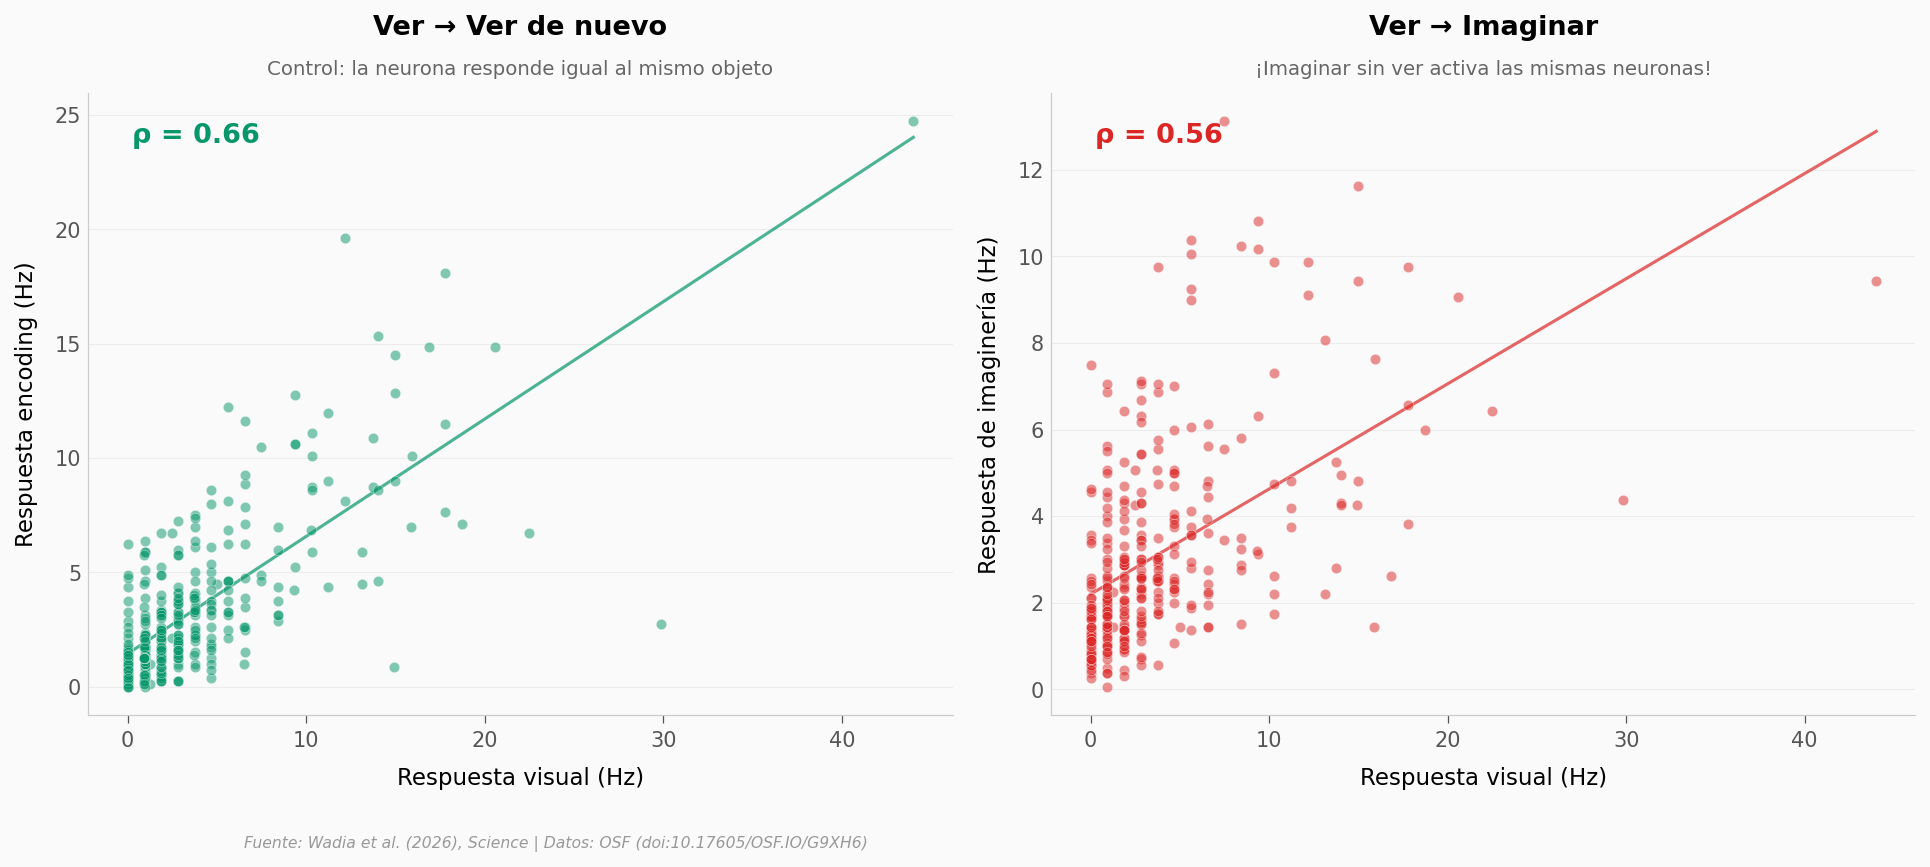

n = 338 pares estímulo-neurona
Ver→Ver: ρ = 0.658
Ver→Imaginar: ρ = 0.559


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: Visual screening vs Encoding (control — misma tarea visual)
ax = axes[0]
x1 = imagery['visual_screening_hz']
y1 = imagery['encoding_hz']
ax.scatter(x1, y1, color=COLOR_ENC, s=25, alpha=0.5,
           edgecolors='white', linewidths=0.3, zorder=5)
# Línea de tendencia
z = np.polyfit(x1, y1, 1)
xline = np.linspace(x1.min(), x1.max(), 100)
ax.plot(xline, np.polyval(z, xline), color=COLOR_ENC, linewidth=1.5, alpha=0.7)

rho_ve, p_ve = stats.spearmanr(x1, y1)
ax.text(0.05, 0.92, f'ρ = {rho_ve:.2f}',
        transform=ax.transAxes, fontsize=13, fontweight='bold', color=COLOR_ENC)
ax.set_xlabel('Respuesta visual (Hz)', fontsize=11)
ax.set_ylabel('Respuesta encoding (Hz)', fontsize=11)
ax.set_title('Ver → Ver de nuevo',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Control: la neurona responde igual al mismo objeto',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')

# Panel 2: Visual screening vs Imagery (¡el hallazgo!)
ax = axes[1]
x2 = imagery['visual_screening_hz']
y2 = imagery['imagery_hz']
ax.scatter(x2, y2, color=COLOR_IMAG, s=25, alpha=0.5,
           edgecolors='white', linewidths=0.3, zorder=5)
z2 = np.polyfit(x2, y2, 1)
ax.plot(xline, np.polyval(z2, xline), color=COLOR_IMAG, linewidth=1.5, alpha=0.7)

rho_vi, p_vi = stats.spearmanr(x2, y2)
ax.text(0.05, 0.92, f'ρ = {rho_vi:.2f}',
        transform=ax.transAxes, fontsize=13, fontweight='bold', color=COLOR_IMAG)
ax.set_xlabel('Respuesta visual (Hz)', fontsize=11)
ax.set_ylabel('Respuesta de imaginería (Hz)', fontsize=11)
ax.set_title('Ver → Imaginar',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '¡Imaginar sin ver activa las mismas neuronas!',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/vision_vs_imagineria.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"n = {len(imagery)} pares estímulo-neurona")
print(f"Ver→Ver: ρ = {rho_ve:.3f}")
print(f"Ver→Imaginar: ρ = {rho_vi:.3f}")

A nivel de población (338 pares estímulo-neurona), la correlación es clara: ρ = 0,56. No tan fuerte como ver el mismo objeto dos veces (ρ = 0,66), pero la señal está ahí. Imaginar un objeto activa un patrón similar —no idéntico— al de verlo.

Pero no todas las neuronas reactivan igual. ¿Cuántas «se prenden» al imaginar?

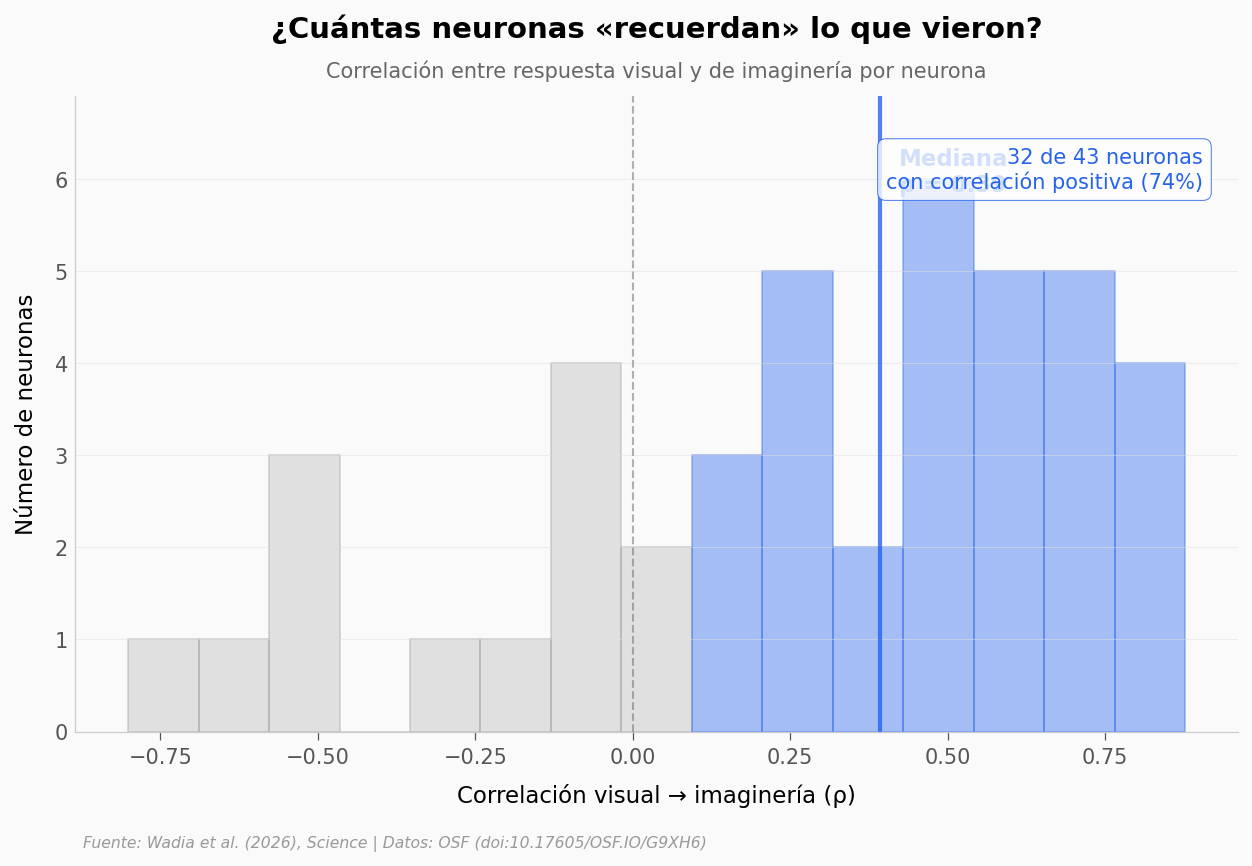

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

rhos = corrs['rho_vis_imag']
n_pos = (rhos > 0).sum()
n_total = len(rhos)

# Histograma
n_bins, bins, patches = ax.hist(rhos, bins=15, color=COLOR_VIS, alpha=0.4,
                                 edgecolor=COLOR_VIS, linewidth=0.8)

# Colorear positivos vs negativos
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 0:
        patch.set_facecolor(COLOR_FONDO)
        patch.set_edgecolor('#999999')

# Línea en cero
ax.axvline(x=0, color='#666666', linewidth=1, linestyle='--', alpha=0.5)

# Mediana
median_rho = rhos.median()
y_max = n_bins.max() * 1.15
ax.axvline(x=median_rho, color=COLOR_VIS, linewidth=2, alpha=0.8)
ax.text(median_rho + 0.03, y_max * 0.85, f'Mediana\nρ = {median_rho:.2f}',
        fontsize=11, color=COLOR_VIS, fontweight='bold')

# Anotación: proporción positivas
ax.text(0.97, 0.92, f'{n_pos} de {n_total} neuronas\ncon correlación positiva ({100*n_pos/n_total:.0f}%)',
        transform=ax.transAxes, fontsize=10, color=COLOR_VIS,
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=COLOR_VIS, alpha=0.8))

ax.set_xlabel('Correlación visual → imaginería (ρ)', fontsize=11)
ax.set_ylabel('Número de neuronas', fontsize=11)
ax.set_title('¿Cuántas neuronas «recuerdan» lo que vieron?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Correlación entre respuesta visual y de imaginería por neurona',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, y_max)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_correlaciones.png', dpi=200, bbox_inches='tight')
plt.show()

74% de las neuronas muestran correlación positiva — su respuesta al imaginar «recuerda» la respuesta al ver. La mediana es ρ = 0,39: moderada, pero consistente. No es una copia perfecta, sino una reactivación parcial del código visual.

¿Pero qué tan rápidas son estas neuronas? La latencia —el tiempo que tarda una neurona en reaccionar al estímulo— nos dice cuándo llega la señal a la VTC.

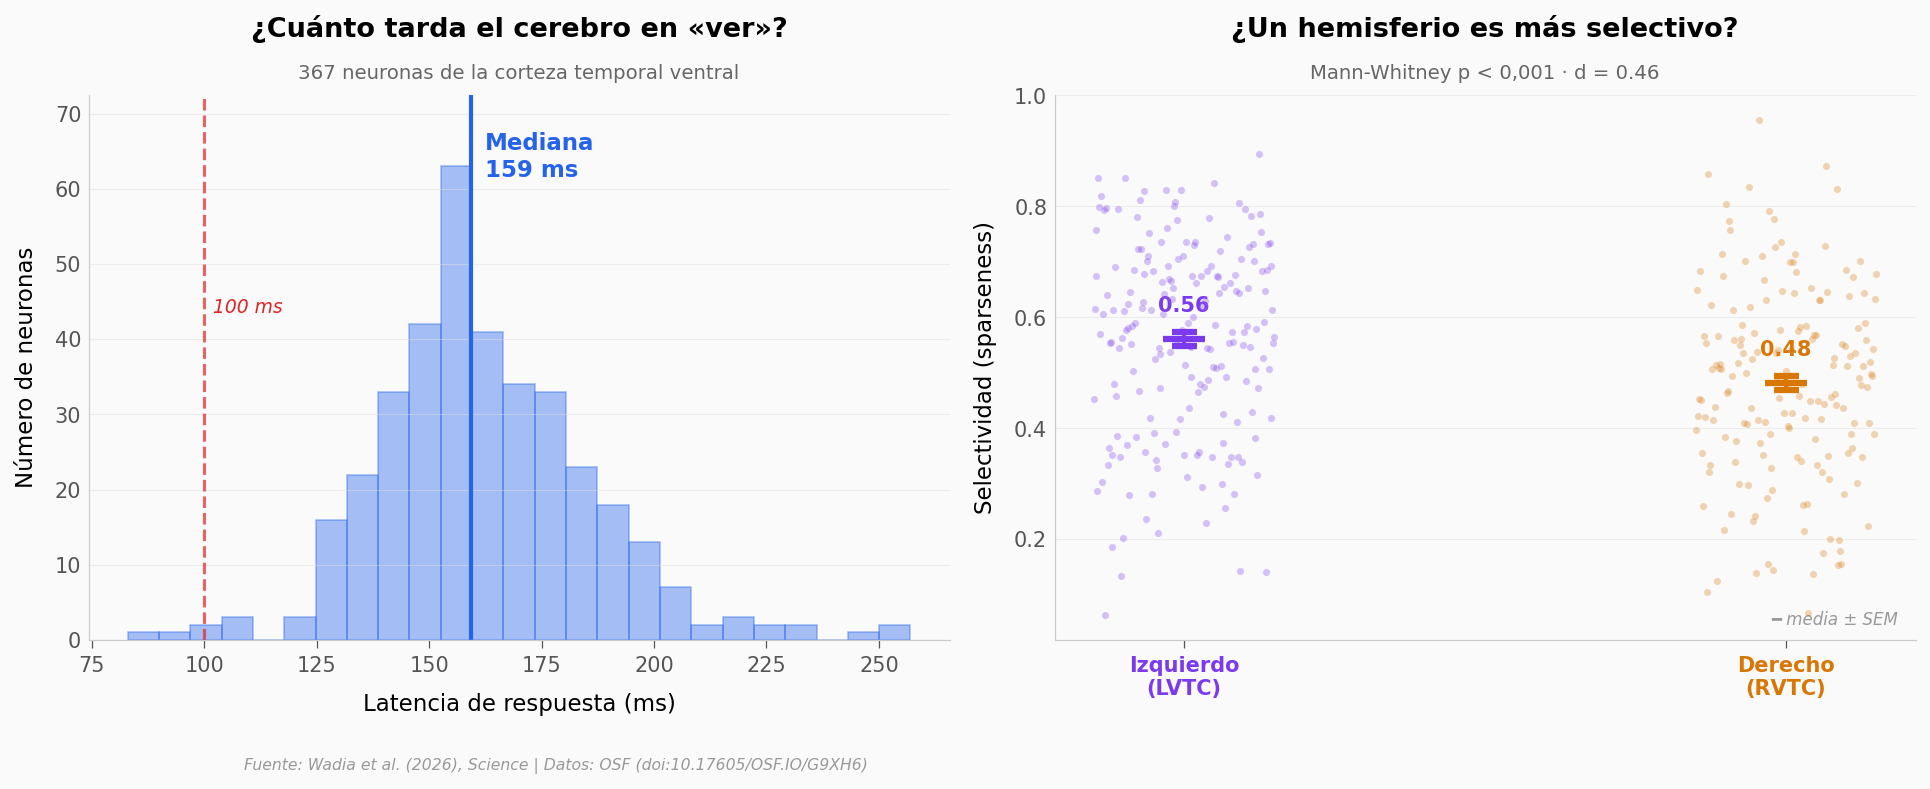

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Distribución de latencias
ax = axes[0]
lat = neurons['latency_ms']
n_bins, bins, patches = ax.hist(lat, bins=25, color=COLOR_VIS, alpha=0.4,
                                 edgecolor=COLOR_VIS, linewidth=0.8)
median_lat = lat.median()
y_max = n_bins.max() * 1.15
ax.axvline(x=median_lat, color=COLOR_VIS, linewidth=2)
ax.text(median_lat + 3, y_max * 0.85, f'Mediana\n{median_lat:.0f} ms',
        fontsize=11, color=COLOR_VIS, fontweight='bold')

# Referencia: 100 ms (tiempo mínimo de procesamiento consciente)
ax.axvline(x=100, color=COLOR_IMAG, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(102, y_max * 0.6, '100 ms',
        fontsize=9, color=COLOR_IMAG, style='italic')

ax.set_xlabel('Latencia de respuesta (ms)', fontsize=11)
ax.set_ylabel('Número de neuronas', fontsize=11)
ax.set_title('¿Cuánto tarda el cerebro en «ver»?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{N_NEURONAS_VIS} neuronas de la corteza temporal ventral',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')
ax.set_ylim(0, y_max)

# Panel 2: Sparseness por hemisferio
ax = axes[1]
lvtc = neurons[neurons['brain_area'] == 'LVTC']['sparseness']
rvtc = neurons[neurons['brain_area'] == 'RVTC']['sparseness']

np.random.seed(42)
positions = [0, 1]
for i, (data, label, color) in enumerate([(lvtc, 'Izquierdo\n(LVTC)', COLOR_HEMI_L),
                                           (rvtc, 'Derecho\n(RVTC)', COLOR_HEMI_R)]):
    n = len(data)
    x_strip = np.linspace(positions[i] - 0.15, positions[i] + 0.15, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, data.values, color=color, s=12, alpha=0.3,
               edgecolors='white', linewidths=0.2, zorder=5)
    mean_val = data.mean()
    sem = data.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean_val, yerr=sem, fmt='_', color=color,
                markersize=20, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(positions[i], mean_val + 0.05, f'{mean_val:.2f}',
            fontsize=10, color=color, fontweight='bold', ha='center')

ax.set_xticks(positions)
ax.set_xticklabels(['Izquierdo\n(LVTC)', 'Derecho\n(RVTC)'], fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_HEMI_L, COLOR_HEMI_R]):
    tick.set_color(color)

ax.set_ylabel('Selectividad (sparseness)', fontsize=11)
ax.set_title('¿Un hemisferio es más selectivo?',
             fontsize=13, fontweight='bold', pad=28)

u_stat, p_val = stats.mannwhitneyu(lvtc, rvtc)
pooled_std = np.sqrt(((len(lvtc)-1)*lvtc.std(ddof=1)**2 + (len(rvtc)-1)*rvtc.std(ddof=1)**2) / (len(lvtc)+len(rvtc)-2))
d = abs(lvtc.mean() - rvtc.mean()) / pooled_std
ax.text(0.5, 1.03, f'Mann-Whitney p < 0,001 · d = {d:.2f}',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/latencia_hemisferios.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ~80% de las neuronas visualmente responsivas usan un código por ejes | ✅ | 367 neuronas con respuestas graduales a 500 estímulos (sparseness mediana: 0,54). Estos datos SON el 80% — el total original no está en el dataset |
| Imaginar reactiva el código visual | ✅ | ρ = 0,56 a nivel de población (n = 338 pares, p < 10⁻²⁸). 74% de las 43 neuronas con correlación positiva |
| ~40% de las neuronas axis-tuned recapitulan el código durante imaginería | ⚠️ | El dataset contiene 43 neuronas reactivadas de 367 axis-tuned (11,7%). El «~40%» del paper se refiere al subconjunto que fue testeado durante imaginería (~108 neuronas estimadas), no a las 367 |
| El hemisferio izquierdo es más selectivo | ✅ | LVTC sparseness = 0,56 vs RVTC = 0,48 (d = 0,46, p < 0,001). Efecto medio |

> **Limitaciones:** (1) Solo 43 neuronas tienen datos de imaginería — muestra pequeña para correlaciones individuales (6-8 estímulos por neurona). (2) Los 16 pacientes son epilépticos con electrodos implantados — la VTC puede diferir de la de personas sin epilepsia. (3) Las 5 categorías de estímulos no están etiquetadas en el dataset público; no pudimos analizar selectividad por categoría semántica. (4) El 40% del paper no se puede verificar directamente porque no tenemos el total de neuronas testeadas durante imaginería.

---

## Ahora tú

1. **¿Hay neuronas «especializadas»?** Al menos una tiene sparseness > 0,9 — responde casi exclusivamente a unos pocos objetos. ¿Cuántas hay con sparseness > 0,85? ¿De qué pacientes?

2. **¿Las neuronas más selectivas son mejores «imaginando»?** ¿Hay correlación entre la sparseness de una neurona y su ρ visual→imaginería?

3. **¿Un paciente contribuye más que los otros?** Con 16 pacientes, la distribución de neuronas es desigual (de 1 a 86 por paciente). ¿Cambian los resultados si excluyes al paciente con más neuronas?

Neuronas con ambos datos: 43
Sparseness: media=0.518, mediana=0.552

Sparseness vs ρ(vis→imag): ρ = 0.307, p = 0.0456
→ Las neuronas más selectivas SÍ tienden a reactivar más durante imaginería


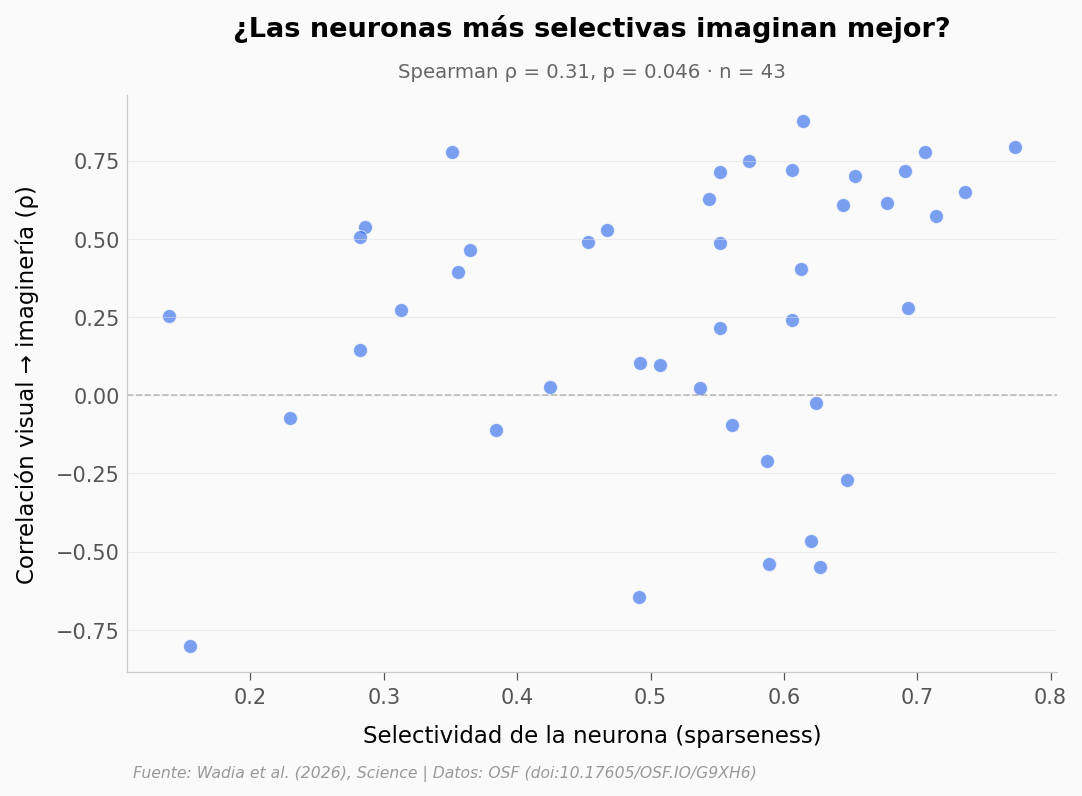

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Las neuronas más selectivas son mejores «imaginando»?

# Asegurar que neuron_id sea string en ambos datasets
corrs['neuron_id'] = corrs['neuron_id'].astype(str)
neurons['neuron_id'] = neurons['neuron_id'].astype(str)

# Para las 43 neuronas de imaginería, necesitamos su sparseness
# Buscar por neuron_id en ambos datasets
merged = corrs.merge(neurons.drop_duplicates('neuron_id')[['neuron_id', 'sparseness', 'brain_area', 'patient_id']],
                     left_on='neuron_id', right_on='neuron_id', how='inner')

print(f"Neuronas con ambos datos: {len(merged)}")
print(f"Sparseness: media={merged['sparseness'].mean():.3f}, mediana={merged['sparseness'].median():.3f}")

# Correlación sparseness vs ρ visual→imaginería
rho_sp, p_sp = stats.spearmanr(merged['sparseness'], merged['rho_vis_imag'])
print(f"\nSparseness vs ρ(vis→imag): ρ = {rho_sp:.3f}, p = {p_sp:.4f}")

if abs(rho_sp) > 0.3 and p_sp < 0.05:
    print("→ Las neuronas más selectivas SÍ tienden a reactivar más durante imaginería")
elif p_sp > 0.05:
    print("→ No hay relación clara entre selectividad y reactivación durante imaginería")
else:
    print(f"→ Relación débil (ρ = {rho_sp:.2f})")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(merged['sparseness'], merged['rho_vis_imag'],
           color=COLOR_VIS, s=45, alpha=0.6, edgecolors='white', linewidths=0.5)
ax.axhline(y=0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Selectividad de la neurona (sparseness)', fontsize=11)
ax.set_ylabel('Correlación visual → imaginería (ρ)', fontsize=11)
ax.set_title('¿Las neuronas más selectivas imaginan mejor?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Spearman ρ = {rho_sp:.2f}, p = {p_sp:.3f} · n = {len(merged)}',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sparseness_vs_imagineria.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Créditos

- **Paper:** Wadia, V. S., Reed, C. M., Chung, J. M., Bateman, L. M., Mamelak, A. N., Rutishauser, U. & Tsao, D. Y. (2026). *A shared code for perceiving and imagining objects in human ventral temporal cortex*. Science. DOI: [10.1126/science.adt8343](https://doi.org/10.1126/science.adt8343)
- **Datos:** Open Science Framework — [doi:10.17605/OSF.IO/G9XH6](https://doi.org/10.17605/OSF.IO/G9XH6) (licencia CC)
- **Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Notebook por:** [Ciencia a Mordiscos](https://cienciaamordiscos.com) · Datos verificados